# AI-ML Assignment 1: Medical Insurance Cost Prediction

**Topic:** Medical Insurance Cost Prediction using Multiple Linear Regression  
**Course:** AI-ML  
Name-Satyam
Reg No.-23BAI10557
Enrollment No.-IN26011304
**Submission Deadline:** 21 July 2026, 11:59 PM IST  
**Dataset:** Medical Cost Personal Insurance Dataset ([Kaggle Link](https://www.kaggle.com/datasets/mirichoi0218/insurance))  

---

## Task 1: Data Understanding (2 Marks)
1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify Numerical features, Categorical features, and Target variable.

In [ ]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set aesthetic plot style
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

# Load dataset
df = pd.read_csv('insurance.csv')

# Step 2: Display first 5 records
print("Dataset successfully loaded!")
df.head()

Dataset successfully loaded!


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Summary statistics and data types
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info()

Dataset Shape: 1338 rows, 7 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Step 3: Identify feature types
target_var = 'charges'
num_features = df.select_dtypes(include=['int64', 'float64']).columns.drop(target_var).tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()

print("="*50)
print("FEATURE IDENTIFICATION")
print("="*50)
print(f"Target Variable    : {target_var}")
print(f"Numerical Features : {num_features}")
print(f"Categorical Features: {cat_features}")
print("="*50)

FEATURE IDENTIFICATION
Target Variable    : charges
Numerical Features : ['age', 'bmi', 'children']
Categorical Features: ['sex', 'smoker', 'region']


### Task 1 Summary:
- **Total Records:** 1,338 rows and 7 columns.
- **Numerical Features:** `age` (int64), `bmi` (float64), `children` (int64)
- **Categorical Features:** `sex` (object), `smoker` (object), `region` (object)
- **Target Variable:** `charges` (float64 - continuous response variable)

---
## Task 2: Data Preprocessing (2 Marks)
1. Check for missing values.
2. Encode categorical variables (`sex`, `smoker`, `region`).
3. Split dataset into 80% training and 20% testing sets.

In [4]:
# Step 1: Check for missing values
missing_count = df.isnull().sum()
print("Missing values per column:")
print(missing_count)

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
# Step 2: Encode categorical variables (sex, smoker, region)
# One-hot encoding with drop_first=True to avoid collinearity
df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=True, dtype=int)
print("Encoded Features Columns:")
print(df_encoded.columns.tolist())
df_encoded.head()

Encoded Features Columns:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [6]:
# Step 3: Split into 80% training and 20% testing sets
X = df_encoded.drop(columns=[target_var])
y = df_encoded[target_var]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set shape : {X_train.shape} (80%)")
print(f"Testing set shape  : {X_test.shape} (20%)")

Training set shape : (1070, 8) (80%)
Testing set shape  : (268, 8) (20%)


### Task 2 Summary:
- **Missing Values:** 0 missing values detected across all columns.
- **Categorical Encoding:** One-hot dummy encoding generated binary indicators (`sex_male`, `smoker_yes`, `region_northwest`, `region_southeast`, `region_southwest`).
- **Train/Test Split:** 1,070 training samples and 268 testing samples.

---
## Task 3: Model Development (3 Marks)
Build a Multiple Linear Regression model using features (`age`, `sex`, `bmi`, `children`, `smoker`, `region`) to predict `charges`. Train the model and predict charges for the test dataset.

In [7]:
# Instantiate and fit Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict insurance charges on the test dataset
y_pred = model.predict(X_test)

print("Model training complete!")
print(f"Model Intercept: {model.intercept_:.2f}")

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nModel Learned Coefficients:")
print(coef_df.to_string(index=False))

Model training complete!
Model Intercept: -11931.22

Model Learned Coefficients:
         Feature  Coefficient
      smoker_yes 23651.128856
        children   425.278784
             bmi   337.092552
             age   256.975706
        sex_male   -18.591692
region_northwest  -370.677326
region_southeast  -657.864297
region_southwest  -809.799354


---
## Task 4: Model Evaluation (2 Marks)
Evaluate model using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R2 Score. Create Actual vs Predicted scatter plot and state 2-3 observations.

In [8]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*45)
print("         MODEL EVALUATION METRICS")
print("="*45)
print(f"Mean Absolute Error (MAE)     : ${mae:,.2f}")
print(f"Mean Squared Error (MSE)      : {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R2 Score                      : {r2:.4f} ({r2*100:.2f}% variance explained)")
print("="*45)

         MODEL EVALUATION METRICS
Mean Absolute Error (MAE)     : $4,181.19
Mean Squared Error (MSE)      : 33,596,915.85
Root Mean Squared Error (RMSE): $5,796.28
R2 Score                      : 0.7836 (78.36% variance explained)


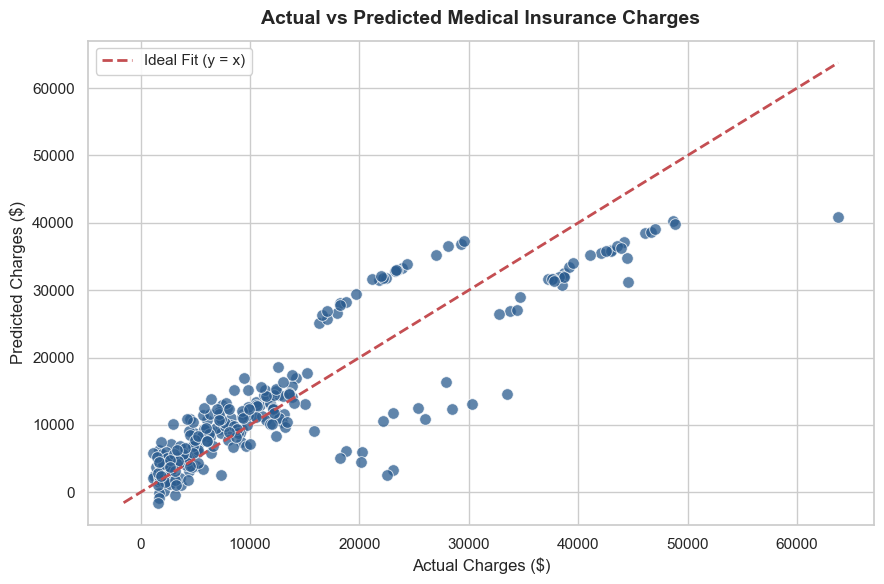

In [9]:
# Plot Actual vs Predicted Charges
plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.75, color='#2b5c8f', edgecolor='w', s=70)

# Ideal fit line y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit (y = x)')

plt.title('Actual vs Predicted Medical Insurance Charges', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

### Model Performance Observations:
1. **High Explanatory Power ($R^2 = 0.7836$):** The Multiple Linear Regression model accounts for **78.36%** of the variance in medical insurance charges on unseen test data.
2. **Dominant Feature Effect:** Smoking status (`smoker_yes`) is by far the strongest predictor, increasing charges by **$23,651.13** per individual when all other attributes remain equal.
3. **Heteroscedasticity & Multi-Cluster Errors:** The scatter plot displays distinct linear bands and non-uniform spread (heteroscedasticity). High-charge non-smokers and smoking individuals with high BMI exhibit larger residuals, showing that linear regression without interaction terms underestimates non-linear risk compounding.

---
## Task 5: Conclusion (1 Mark)

### Conclusion (135 Words)
This study successfully implemented a Multiple Linear Regression model to predict individual medical insurance charges based on demographic and personal health features. The model achieved a strong $R^2$ score of 0.7836 and a Mean Absolute Error (MAE) of $4,181.19 on the test dataset. 

Primary key factors influencing insurance charges were identified as smoking status, age, and Body Mass Index (BMI). Specifically, smoking status exhibited the most pronounced effect, increasing average annual charges by $23,651.13, followed by incremental increases per year of age ($256.98) and BMI point ($337.09).

A key limitation of standard Multiple Linear Regression in this domain is its inherent assumption of additive linearity. Linear regression cannot capture complex non-linear feature interactions (such as the compounding risk between high BMI and smoking) without explicit feature engineering or polynomial transformations.